In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [4]:
data = pd.read_csv('heart.csv')
data[data['RestingBP'] == 0 ]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


# EDA<!--  -->

In [5]:
# Step1 : Viewing data
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
data.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [7]:
data.shape

(918, 12)

In [8]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [9]:
data.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [10]:
# Summery Statistics
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [11]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [12]:
# Step 3 ==> Value counts
col = data.select_dtypes(include='object')
for c in col:
    print(col[c].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [13]:
data['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [14]:
# Step 4 : Missing value analysis
data.isnull()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
913,False,False,False,False,False,False,False,False,False,False,False,False
914,False,False,False,False,False,False,False,False,False,False,False,False
915,False,False,False,False,False,False,False,False,False,False,False,False
916,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease'>

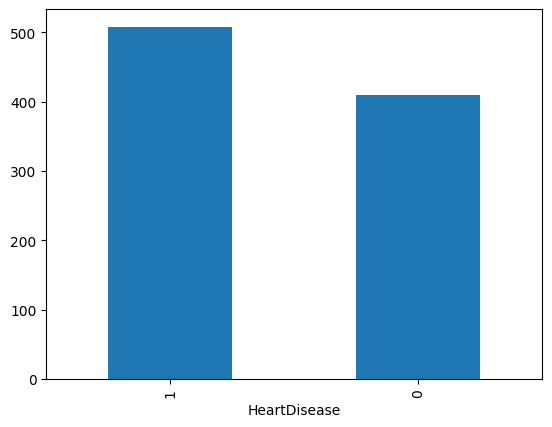

In [16]:
# Step 5 : Visualization
data['HeartDisease'].value_counts().plot(kind='bar')

In [17]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

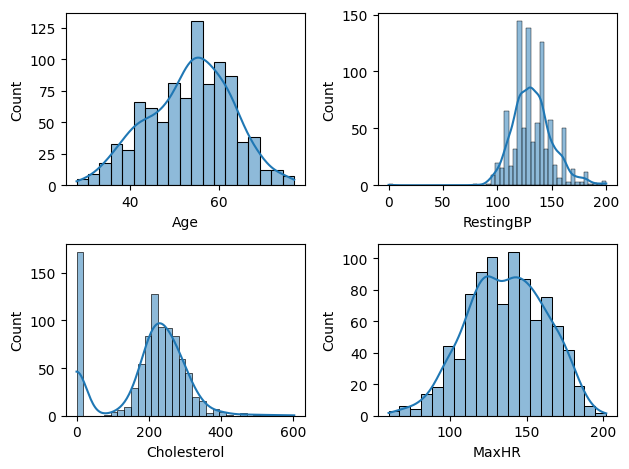

In [18]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [19]:
data['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [20]:
data[data['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [21]:
# Not any person has 0 RastingBP even hearts stop RestingBp doesn't flow to zero 

In [22]:
data['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [23]:
data[data['Cholesterol'] == 0].count()

Age               172
Sex               172
ChestPainType     172
RestingBP         172
Cholesterol       172
FastingBS         172
RestingECG        172
MaxHR             172
ExerciseAngina    172
Oldpeak           172
ST_Slope          172
HeartDisease      172
dtype: int64

In [24]:
# Cholesterol is not 0 

In [25]:
# Step 6 Target Variable exploration
data['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [26]:
# Now cleaning The data 
# 1 - handle Missing value
# 2 - Remove Duplicates
# 3 - Fix Data types
# 4 - Handle inconsistent categories
# 5 - Detect and handle outliers
# 6 - Fix logic and domain errors

In [27]:
# 1
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [28]:
# 2 
data.drop_duplicates(inplace=True)

In [29]:
data.shape

(918, 12)

In [30]:
# 3 
data.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [31]:
# 4 
# 5 
# 6


In [32]:
# filling missing value of Cherostreol
ch_mean = data.loc[data['Cholesterol'] != 0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [33]:
ch_meanq = data['Cholesterol'].replace(0,np.nan).mean()
ch_meanq

np.float64(244.6353887399464)

In [34]:
data['Cholesterol'] = data['Cholesterol'].replace(0,ch_mean)

In [35]:
data['Cholesterol']

0      289.0
1      180.0
2      283.0
3      214.0
4      195.0
       ...  
913    264.0
914    193.0
915    131.0
916    236.0
917    175.0
Name: Cholesterol, Length: 918, dtype: float64

In [36]:
re_mean = data['RestingBP'].replace(0,np.nan).mean()
re_mean

np.float64(132.54089422028352)

In [37]:
re_mean = data.loc[data['RestingBP'] != 0,'RestingBP'].mean()
re_mean

np.float64(132.54089422028352)

In [38]:
data['RestingBP'] = data['RestingBP'].replace(0,re_mean)

In [39]:
data['RestingBP'] = data['RestingBP'].round(2)

In [40]:
data[data['Age'] == 55]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
74,55,M,ASY,140.00,268.000000,0,Normal,128,Y,1.5,Flat,1
80,55,M,NAP,110.00,277.000000,0,Normal,160,N,0.0,Up,0
89,55,M,ASY,140.00,229.000000,0,Normal,110,Y,0.5,Flat,0
153,55,M,ASY,120.00,270.000000,0,Normal,140,N,0.0,Up,0
218,55,M,ATA,140.00,196.000000,0,Normal,150,N,0.0,Up,0
224,55,M,ATA,120.00,256.000000,1,Normal,137,N,0.0,Up,0
237,55,M,TA,140.00,295.000000,0,Normal,136,N,0.0,Flat,1
240,55,M,ATA,145.00,326.000000,0,Normal,155,N,0.0,Up,0
242,55,M,ATA,160.00,292.000000,1,Normal,143,Y,2.0,Flat,1
254,55,M,ASY,145.00,248.000000,0,Normal,96,Y,2.0,Flat,1


In [41]:
data[data['Cholesterol'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [42]:
data['RestingBP'] = data['RestingBP'].replace(0,re_mean)
data['RestingBP'] = data['RestingBP'].round(2)

In [43]:
data['Cholesterol'] = data['Cholesterol'].replace(0,ch_mean)
data['Cholesterol'] = data['Cholesterol'].round(2)

In [44]:
# For analysis of categorical columns we use count_plot

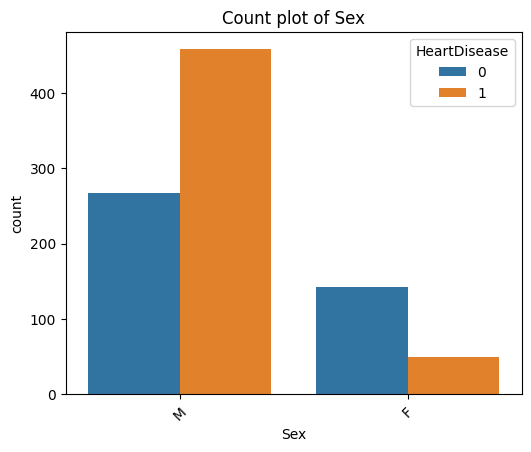

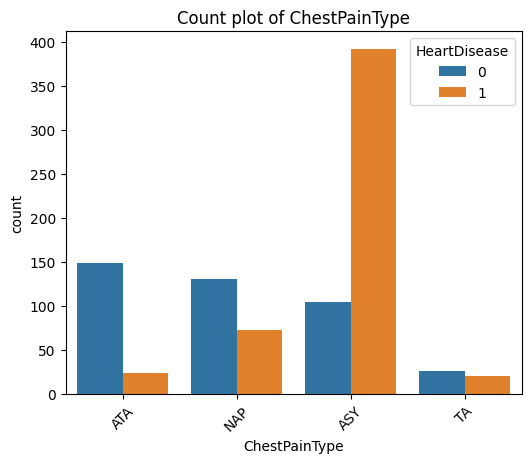

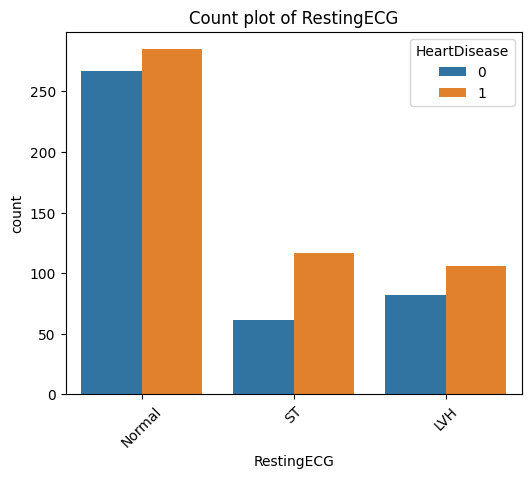

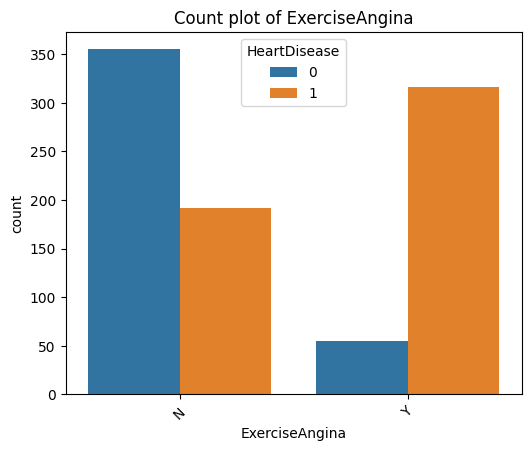

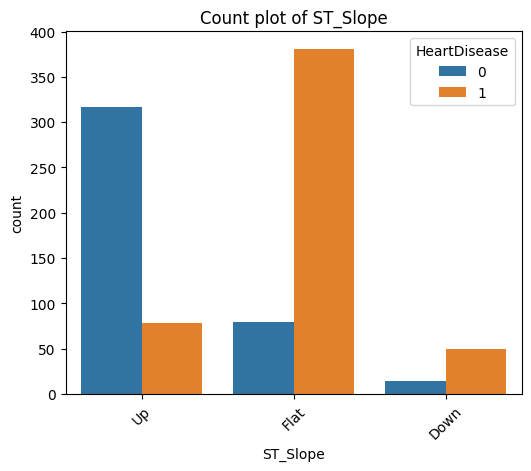

<Figure size 640x480 with 0 Axes>

In [45]:
for idx,c in enumerate(col):
    plt.figure(figsize=(20,16))
    plt.subplot(3,3,idx+1)
    sns.countplot(x = data[c],hue=data['HeartDisease'])
    plt.title(f"Count plot of {c}")
    plt.xticks(rotation=45)

    plt.show()
plt.tight_layout()

In [46]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

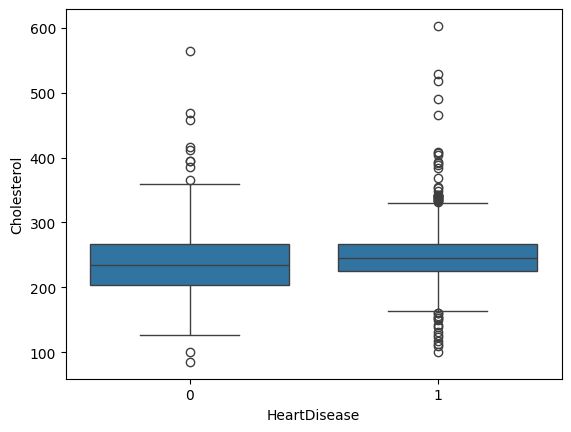

In [47]:
sns.boxplot(y='Cholesterol',x='HeartDisease',data=data)

<Axes: xlabel='HeartDisease', ylabel='Age'>

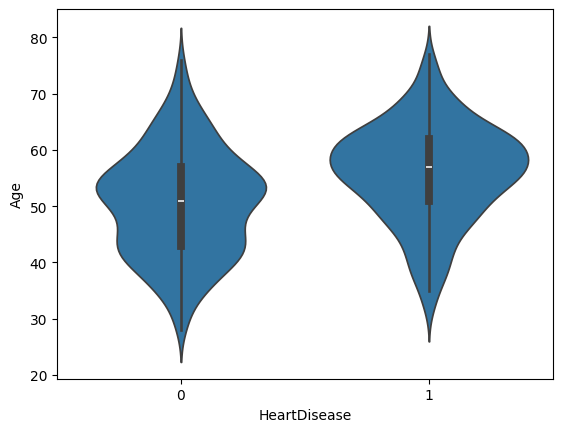

In [48]:
sns.violinplot(x='HeartDisease',y='Age',data=data)

<Axes: >

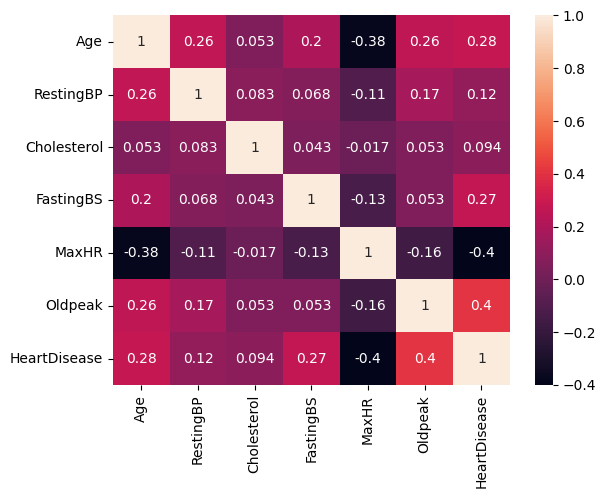

In [49]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

In [50]:
# Data Processing

In [51]:
data = pd.get_dummies(data,drop_first=True).astype(int)
data.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()
numerical_col = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
data[numerical_col] = scaler.fit_transform(data[numerical_col])
data.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [54]:
data.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [80]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

In [56]:
x = data.drop('HeartDisease',axis=1)
y = data['HeartDisease']

In [62]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [67]:
scaler = StandardScaler()

In [70]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [90]:
models = {
    "Logistic Regression":LogisticRegression(),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
    "Decision Tree ": DecisionTreeClassifier(random_state=42),
    "SVC" : SVC(kernel="rbf"),
    "Naive Bayes" : GaussianNB(),
    "Random Forest ":RandomForestClassifier(random_state=42)
}

In [91]:
result = []

In [92]:
for name,model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        "Model" : name,
        "Accuracy" :round(acc,4),
        "f1-score" :round(f1,4),
    })

In [93]:
result

[{'Model': 'Logistic Regression', 'Accuracy': 0.8696, 'f1-score': 0.8857},
 {'Model': 'KNN', 'Accuracy': 0.8641, 'f1-score': 0.8815},
 {'Model': 'Decision Tree ', 'Accuracy': 0.7826, 'f1-score': 0.802},
 {'Model': 'SVC', 'Accuracy': 0.8478, 'f1-score': 0.8679},
 {'Model': 'Naive Bayes', 'Accuracy': 0.8533, 'f1-score': 0.8683},
 {'Model': 'Random Forest ', 'Accuracy': 0.8533, 'f1-score': 0.872}]

In [ ]:
import joblib 
joblib.dump(models['Logistic Regression'],'LR_heart_diese.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'X_Columns.pkl')